# OneMath World School 2026 
# Topological Data Analysis and Applications
# Euler Characterstic Transform 

A simplicial complex is a combinatorial object consisting of building blocks of increasing dimension: vertices, edges, triangles, tetrahedra, and higher dimensional analogues. Specifically, a (geometric) $k$-simplex is the convex hull of $k + 1$ affinely independent points in
$\mathbb{R}^d$, denoted $\sigma = \{v_0, · · · , v_k\}$. A simplex $\tau$ is a face of a simplex $\sigma$ if the vertex
sets are nested, i.e. $\tau \subseteq \sigma$: in this case we write $\tau \leq \sigma$. A (geometric) simplicial complex $K$ consists
of a set of geometric simplices in $\mathbb{R}^d$ such that (i) every face of a simplex in $K$ is also in $K$; and
(ii) if two simplices $\sigma$ and $\tau$ are in $K$, then their intersection is either empty or a face of both. 

The *Euler characteristic* of a simplicial complex $K$ is an alternating sum of counts of simplices in each dimension. Specifically, if $c_p$ is the number of $p$-simplices in $K$, then:
$$ \chi(K) = \sum_{p} (-1)^p c_p = c_0 - c_1 + c_2 - c_3 + \cdots $$
It is known that two homeomorphic spaces have same Euler characteristic but the converse is not true.

Given a simplicial complex $K \subset \mathbb{R}^d$ and a fixed direction $\omega \in \mathbb{S}^{d-1}$, we define a simplex-wise filtration function $f_\omega: K \to \mathbb{R}$ by:

$$ f_\omega(\sigma) = \max_{v \in \sigma} \langle v, \omega \rangle $$

where $\langle v, \omega \rangle$ is the standard dot product. The sublevel sets $K_a = \{ \sigma \in K \mid f_\omega(\sigma) \le a \}$ form valid simplicial complexes for any $a \in \mathbb{R}$. Note that if we consider a plane passing through the origin whose normal is $\omega$. Then the filtration function is just the maximum signed perpendicular distance of all the vertices from the plane. Thus a sublevel set $K_a$ is subsimplex whose all vertices are at most $a$ distance away from the plane. 

The *Euler Characteristic Curve (ECC)* for direction $\omega$ tracks the Euler characteristic of these sublevel sets:

$$ \text{ECC}_\omega: \mathbb{R} \to \mathbb{Z}, \quad a \mapsto \chi(K_a) $$

**Definition** Given a simplicial complex $K$ embedded in $\mathbb{R}^d$, the *Euler Characteristic Transform (ECT)* is defined as:

$$ \text{ECT}(K): \mathbb{S}^{d-1} \to \mathbb{Z}^{\mathbb{R}} $$
$$ \omega \mapsto \text{ECC}_\omega $$

where $\mathbb{Z}^{\mathbb{R}}$ denotes the set of functions from $\mathbb{R}$ to $\mathbb{Z}$.

**Theorem 1**: The ECT is injective on the space of constructible sets in $\mathbb{R}^d$. Check [An Invitation to the Euler Characteristic Transform](https://arxiv.org/abs/2310.10395) for more details.

## Installing ECT

To install ect, run the following in a terminal. <br>
`pip install ect` <br>
Python 3.10 (or higher) is required for this package. 

## Creating Simplicial Complexes

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ect import EmbeddedComplex, ECT, Directions
from ect.utils.examples import create_example_graph, create_example_cw, create_example_3d_complex

We start by creating an 1-simplex. 1-simplex consists of 2 vertices and convex hull of 2 vertices which is a line segment joining 2 vertices.

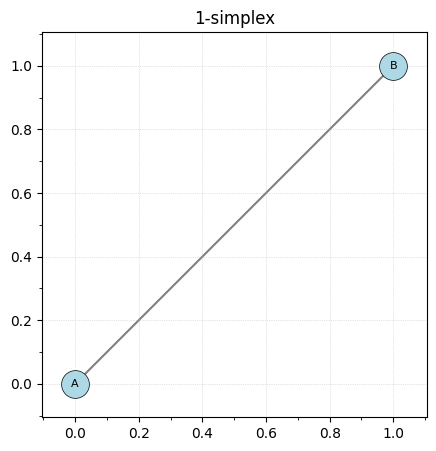

Vertices: [('A', {}), ('B', {})]
Edges: [('A', 'B')]


In [12]:
# Intialize an embedded complex
K = EmbeddedComplex()

# add vertices
K.add_node('A', coord=[0, 0])
K.add_node('B', coord=[1, 1])

# add the line segment between A and B (edge)
K.add_edge('A', 'B')

# visualize the complex
fig, ax = plt.subplots(figsize=(5, 5))
K.plot(ax=ax, with_labels=True, node_size=400)
ax.set_title("1-simplex")
plt.show()

print("Vertices:", K.nodes(data=True))
print("Edges:", K.edges())

Let's create a 2-simplex. This consists of three vertices, the three 1-simplices (edges) connecting them, and the single 2-simplex (face) bounded by those edges, which is nothing but a triangle with face.

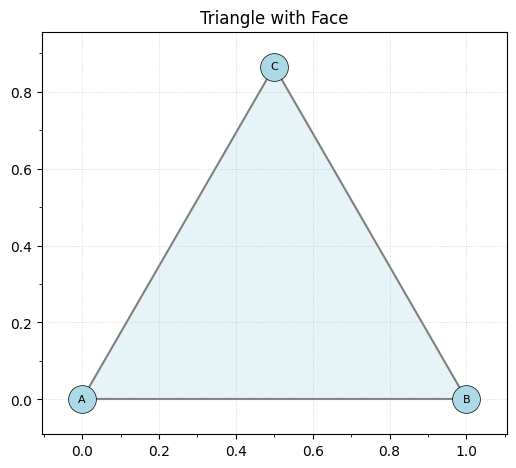

Number of faces: 1
Faces: [('A', 'B', 'C')]


In [24]:
# Initialize an embedded complex
K_tri = EmbeddedComplex()

# add the 3 vertices
K_tri.add_node('A', coord=[0, 0])
K_tri.add_node('B', coord=[1, 0])
K_tri.add_node('C', coord=[0.5, 0.866])

# add the edges (1-simplices)
K_tri.add_edge('A', 'B')
K_tri.add_edge('B', 'C')
K_tri.add_edge('C', 'A')

# add the face (2-simplex)
K_tri.add_face(['A', 'B', 'C'])

# visualize the complex
fig, ax = plt.subplots(figsize=(6, 6))
K_tri.plot(ax=ax, with_labels=True, node_size=400, face_alpha=0.3, face_color='lightblue')
ax.set_title('Triangle with Face')
plt.show()

print(f"Number of faces: {len(K_tri.faces)}")
print(f"Faces: {K_tri.faces}")


A graph is a simple example of a simplicial complex. Let's create a simple simplicial complex with 4 vertices. 

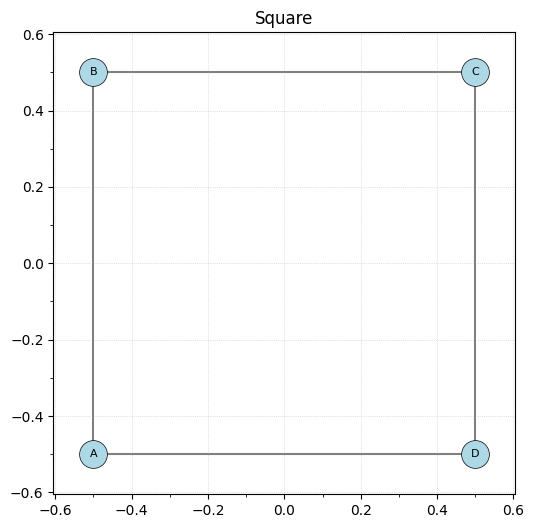

In [69]:
K_sq = EmbeddedComplex()

# add the 4 vertices
K_sq.add_node('A', coord=[-0.5, -0.5])
K_sq.add_node('B', coord=[-0.5, 0.5])
K_sq.add_node('C', coord=[0.5, 0.5])
K_sq.add_node('D', coord=[0.5, -0.5])

# add the edges (1-simplices)
K_sq.add_edge('A', 'B')
K_sq.add_edge('B', 'C')
K_sq.add_edge('C', 'D')
K_sq.add_edge('D', 'A')

# visualize the complex
fig, ax = plt.subplots(figsize=(6, 6))
K_sq.plot(ax=ax, with_labels=True, node_size=400)
ax.set_title('Square')
plt.show()

This simplicial complex $K_{sq}$ consists of 4 1-simplicies, with face of each included in $K_{sq}$ and thier intersections are vertices which are faces(0-dimensional) of both. 

## ECC

If we fix the direction along y-axis then the filtration function along this direction is the maximum height(y-coordinate) among all the vertices. Hence, the sublevel simplicial complex $K_a$ is a simplicial complex formed by vertices whose height is less than $a$. We will compute ECC along y-axis. 

### ECC along y-axis of 2-simplex (traingle with face)

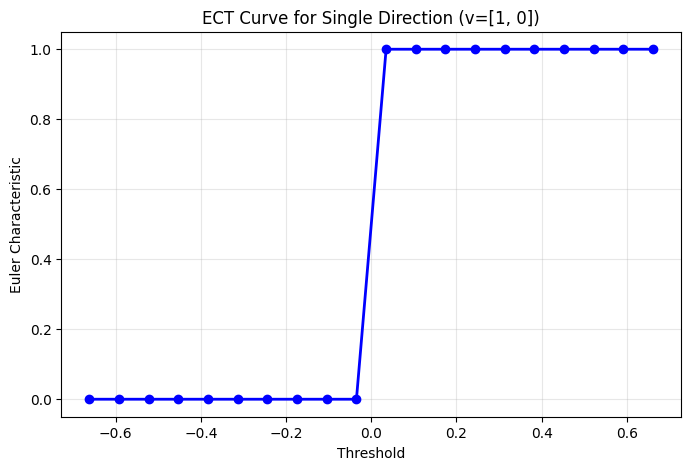

In [25]:
# define direction
dir = Directions.from_vectors([[1, 0]])

# Define ECT object with specified number of thresholds and direction
ECT_obj = ECT(num_thresh=20, directions=dir)

# Compute ECT for the 2-simplex
single_direction = ECT_obj.calculate(K_tri)

# Plot the ECT curve for the single direction
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(single_direction.thresholds, single_direction[0], 'b-', marker='o', linewidth=2)
ax.set_xlabel('Threshold')
ax.set_ylabel('Euler Characteristic')
ax.set_title('ECT Curve for Single Direction (v=[1, 0])')
ax.grid(True, alpha=0.3)
plt.show()

The parameter `num_thresh = 20` divide the closed interval $[-1, 1]$ in 20 equal parts. A sublevel simplicial complex is formed for each of these points and then ECT is computed for these sublevel complexes. The `directions` parameter defines the directions for computing ECT. Here we are only interested in ECC thus we are passing only one direction.

**Explaination:**
There is no vertex with height less than 0 therefore $\chi = 0$ for $a < 0$. The sublevel complex for $ 0 \leq a <0.866$ is a line segment which has $\chi = 1$. For $a \geq 0.866$, the sublevel complex is triangle with face whose $\chi = 1$. 


### ECC along y-axis of square

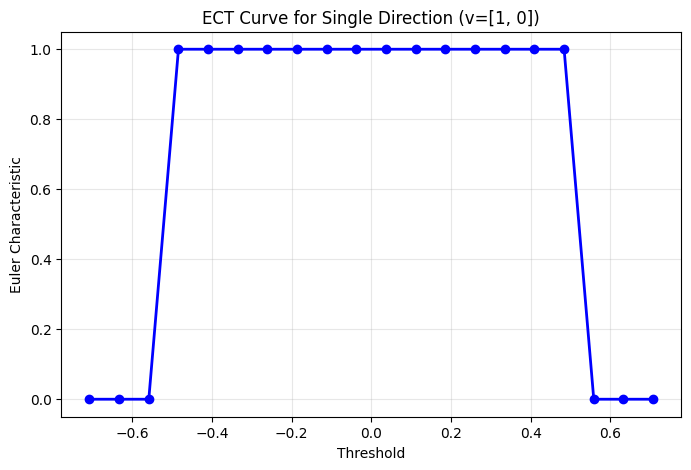

In [77]:
# define direction
dir = Directions.from_vectors([[1, 0]])

# Define ECT object with specified number of thresholds and direction
ECT_obj = ECT(num_thresh=20, directions=dir)

# Compute ECT for the square
single_direction = ECT_obj.calculate(K_sq)

# Plot the ECT curve for the single direction
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(single_direction.thresholds, single_direction[0], 'b-', marker='o', linewidth=2)
ax.set_xlabel('Threshold')
ax.set_ylabel('Euler Characteristic')
ax.set_title('ECT Curve for Single Direction (v=[1, 0])')
ax.grid(True, alpha=0.3)
plt.show()

For $a < -0.5$, the sublevel complex is empty hence $\chi = 0$, for $ -0.5 \leq a < 0.5$ the sublevel complex is line segement, thus $\chi = 0$. Fro $a \geq 0.5$, the sublevel complex is square hence $\chi = 0.$

Let's create a little complicated graph and look at its ECC.

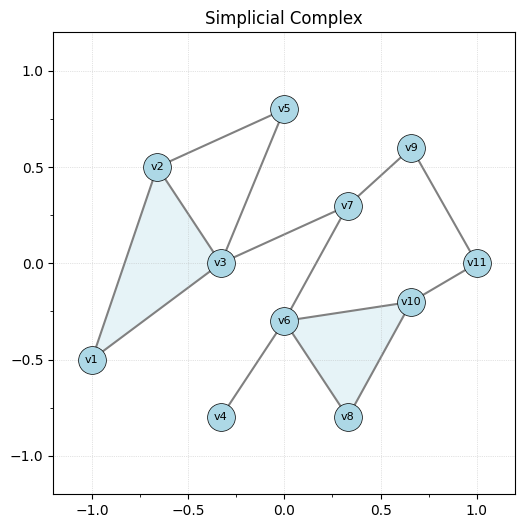

In [ ]:
# Create the complex object
K = EmbeddedComplex()

# Add vertices
K.add_node('v1', coord=[-1.0, -0.5])   

K.add_node('v2', coord=[-0.66, 0.5])   

K.add_node('v3', coord=[-0.33, 0.0])  
K.add_node('v4', coord=[-0.33, -0.8])  

K.add_node('v5', coord=[0.0, 0.8])    

K.add_node('v6', coord=[0.0, -0.3])   
K.add_node('v7', coord=[0.33, 0.3])   

K.add_node('v8', coord=[0.33, -0.8])   

K.add_node('v9', coord=[0.66, 0.6])    
K.add_node('v10', coord=[0.66, -0.2])  

K.add_node('v11', coord=[1.0, 0.0])    


# Add edges

K.add_edge('v1', 'v2')
K.add_edge('v2', 'v3')
K.add_edge('v3', 'v1')


K.add_edge('v2', 'v5')
K.add_edge('v5', 'v3')


K.add_edge('v3', 'v7')


K.add_edge('v6', 'v4') 


K.add_edge('v7', 'v6')


K.add_edge('v6', 'v8')
K.add_edge('v8', 'v10')
K.add_edge('v10', 'v6')


K.add_edge('v7', 'v9')
K.add_edge('v9', 'v11')


K.add_edge('v10', 'v11')

# Add faces
K.add_face(['v1', 'v2', 'v3'])  
K.add_face(['v6', 'v8', 'v10'])  

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
K.plot(ax=ax, with_labels=True, node_size=400, face_alpha=0.3, face_color='lightblue') 
ax.set_title('Simplicial Complex K')
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
plt.show()

Change the variable `dir` to visualize the ECC along different directions. The variable should be a list of coordinates of a unit vector in 2D. 

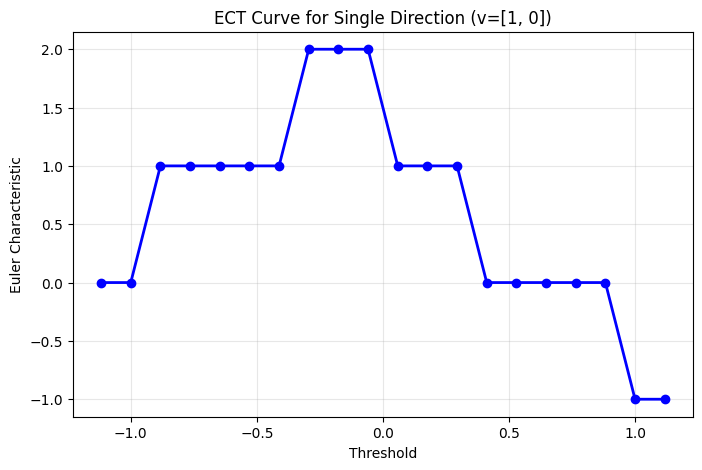

In [54]:
# define direction (change it to see ECC in different directions)
dir = [1, 0]

# Define ECT object with specified number of thresholds and direction
ECT_obj = ECT(num_thresh=20, directions=Directions.from_vectors([dir]))

# Compute ECT for the square
single_direction = ECT_obj.calculate(K)

# Plot the ECT curve for the single direction
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(single_direction.thresholds, single_direction[0], 'b-', marker='o', linewidth=2)
ax.set_xlabel('Threshold')
ax.set_ylabel('Euler Characteristic')
ax.set_title(f'ECT Curve for Single Direction (v={dir})')
ax.grid(True, alpha=0.3)
plt.show()

## Computing the ECT

We will first compute ECT matrix for the square. 

ECT result shape: (8, 20)
Directions: 8 directions in 2D
Thresholds: 20 threshold values


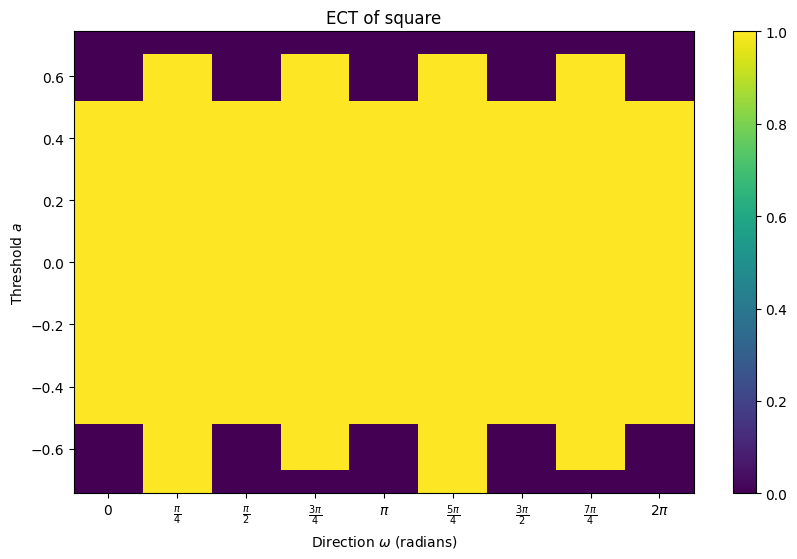

In [81]:
# Define ECT object 
ect = ECT(num_dirs=8, num_thresh=20)

# Compute ECT
result = ect.calculate(K_sq)

print(f"ECT result shape: {result.shape}")
print(f"Directions: {len(result.directions)} directions in {K_sq.dim}D")
print(f"Thresholds: {len(result.thresholds)} threshold values")

# Plot the ECT matrix
fig, ax = plt.subplots(figsize=(10, 6))
result.plot()
plt.title('ECT of square')
plt.show()


`num_dirs=8`: The 8 directions from $S^1$ are selected by parametrizing the $S^1$ using the angle. <br>
The varying height of the yellow blocks effectively captures the width vs diagonal length of the square.

To show how ECT captures the shape of the object we will compute the ECT of the circle (circle like graph). Can you guess what the ECT of circle look like?

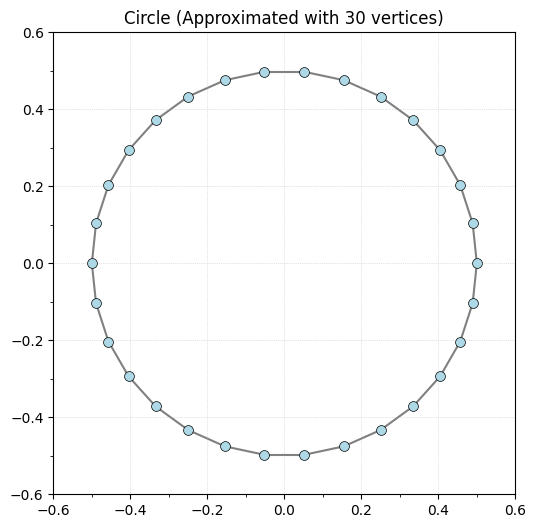

In [83]:
K_circle = EmbeddedComplex()
# Parameters for the circle
radius = 0.5
num_vertices = 30  # Higher number = smoother circle

# Add Vertices
for i in range(num_vertices):
    # Calculate angle for this vertex (0 to 2*pi)
    theta = 2 * np.pi * i / num_vertices
    
    # Polar to Cartesian coordinates: x = r*cos(theta), y = r*sin(theta)
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)
    
    K_circle.add_node(f'v{i}', coord=[x, y])

# Add Edges
for i in range(num_vertices):
    # Connect current vertex to the next one
    start_node = f'v{i}'
    end_node = f'v{(i + 1) % num_vertices}'
    
    K_circle.add_edge(start_node, end_node)

# Visualize
fig, ax = plt.subplots(figsize=(6, 6))
K_circle.plot(ax=ax, with_labels=False, node_size=50) 
ax.set_title(f'Circle (Approximated with {num_vertices} vertices)')
ax.set_xlim(-0.6, 0.6)
ax.set_ylim(-0.6, 0.6)
plt.show()


ECT result shape: (8, 20)
Directions: 8 directions in 2D
Thresholds: 20 threshold values


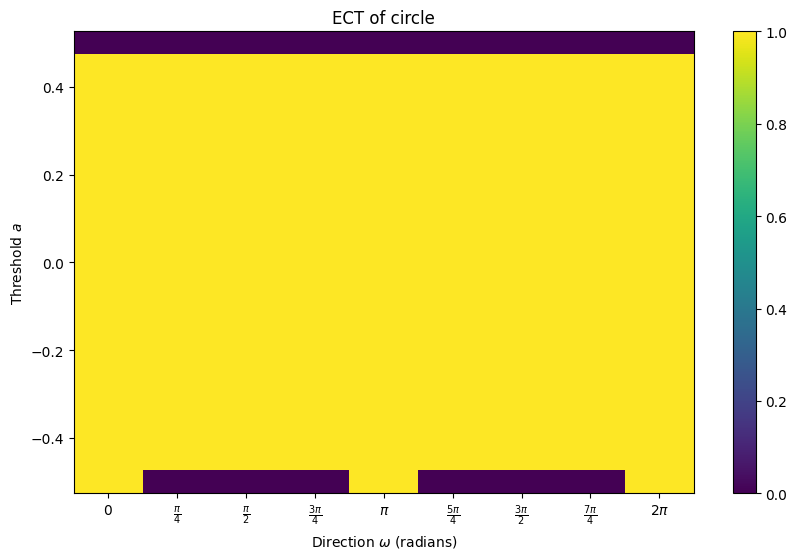

In [87]:
# Define ECT object 
ect = ECT(num_dirs=8, num_thresh=20)

# Compute ECT
result = ect.calculate(K_circle)

print(f"ECT result shape: {result.shape}")
print(f"Directions: {len(result.directions)} directions in {K_circle.dim}D")
print(f"Thresholds: {len(result.thresholds)} threshold values")

# Plot the ECT matrix
fig, ax = plt.subplots(figsize=(10, 6))
result.plot()
plt.title('ECT of circle')
plt.show()

ECT result shape: (4, 20)
Directions: 4 directions in 2D
Thresholds: 20 threshold values


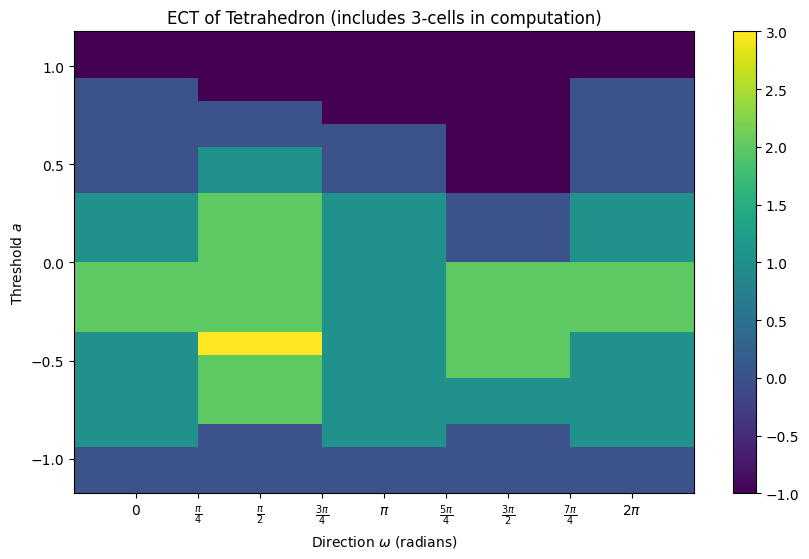

In [67]:
# Define ECT object
ect = ECT(num_dirs=4, num_thresh=20)

# Compute ECT
result = ect.calculate(K)

print(f"ECT result shape: {result.shape}")
print(f"Directions: {len(result.directions)} directions in {K.dim}D")
print(f"Thresholds: {len(result.thresholds)} threshold values")

# Plot the ECT matrix
fig, ax = plt.subplots(figsize=(10, 6))
result.plot()
plt.title('ECT of Tetrahedron (includes 3-cells in computation)')
plt.show()